**1: Setup Environment & Dependencies**

In [1]:
# 1. Install library YOLOv8 (Ultralytics)
!pip install ultralytics -q

# 2. Import semua library yang dibutuhkan
import os
import random
import shutil
from ultralytics import YOLO
from IPython.display import Image, display

print("Setup selesai! Dependensi berhasil dimuat.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.8 MB/s eta 0:00:00a 0:00:01
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Setup selesai! Dependensi berhasil dimuat.


**2: Data Preparation & Model Implementation (Training)**

In [2]:
import os
from ultralytics import YOLO

print("Menyiapkan konfigurasi arsitektur data...")

# 1. Mendefinisikan Path Absolute Kaggle
# Menambahkan sub-folder 
base_path = '/kaggle/input/datasets/nadinpethiyagoda/vehicle-dataset-for-yolo/vehicle dataset'
train_path = f"{base_path}/train/images"
val_path   = f"{base_path}/valid/images"

# 2. Membuat file konfigurasi YAML dengan 6 kelas yang seimbang
yaml_content = f"""
train: {train_path}
val: {val_path}

nc: 6
names: ['Car', 'Threewheel', 'Bus', 'Truck', 'Motorbike', 'Van']
"""

with open('traffic_data.yaml', 'w') as f:
    f.write(yaml_content.strip())
print("File traffic_data.yaml berhasil dibuat.")

print("\nMemulai proses training YOLOv8 Small dengan dataset terdistribusi seimbang...")

# 3. Memuat model dan mengeksekusi training
model = YOLO('yolov8s.pt')

results = model.train(
    data='traffic_data.yaml',
    epochs=100,                 
    patience=20,                
    imgsz=640,                  
    batch=16,                   
    plots=True,                 
    project='smart_traffic',    
    name='training_run_v3'      
)

print("Proses training tahap ketiga selesai.")

Menyiapkan konfigurasi arsitektur data...
File traffic_data.yaml berhasil dibuat.

Memulai proses training YOLOv8 Small dengan dataset terdistribusi seimbang...
Ultralytics 8.4.46 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=traffic_data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, mo

**3: Inference & Testing (Tugas 5-10 Sampel)**

In [3]:
import os
import glob
import random
from ultralytics import YOLO

print("Memulai proses inference pada 10 sampel gambar validasi...")

# 1. Mendefinisikan path dataset validasi 
val_path = '/kaggle/input/datasets/nadinpethiyagoda/vehicle-dataset-for-yolo/vehicle dataset/valid/images'

# 2. Mencari otomatis file best.pt dari direktori training terbaru
weight_files = glob.glob('/kaggle/working/**/best.pt', recursive=True)

if not weight_files:
    print("ERROR: Model terbaik tidak ditemukan.")
else:
    # Mengambil best.pt yang paling baru dibuat
    best_model_path = max(weight_files, key=os.path.getctime)
    print(f"Model terbaik ditemukan dan dimuat dari: {best_model_path}")
    best_model = YOLO(best_model_path)

    # 3. Mengambil 10 gambar acak
    all_val_images = [f for f in os.listdir(val_path) if f.endswith(('.jpg', '.png', '.jpeg'))]
    test_samples = random.sample(all_val_images, min(10, len(all_val_images)))

    # 4. Mengeksekusi prediksi
    for img_name in test_samples:
        img_path = os.path.join(val_path, img_name)
        best_model.predict(
            source=img_path,
            save=True,
            conf=0.4,
            project='smart_traffic',
            name='inference_v3_results',
            exist_ok=True
        )

    print("Inference selesai. Gambar tersimpan di direktori smart_traffic/inference_v3_results.")

Memulai proses inference pada 10 sampel gambar validasi...
Model terbaik ditemukan dan dimuat dari: /kaggle/working/runs/detect/smart_traffic/training_run_v3/weights/best.pt

image 1/1 /kaggle/input/datasets/nadinpethiyagoda/vehicle-dataset-for-yolo/vehicle dataset/valid/images/car134.jpg: 480x640 1 Car, 44.7ms
Speed: 2.9ms preprocess, 44.7ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /kaggle/working/runs/detect/smart_traffic/inference_v3_results

image 1/1 /kaggle/input/datasets/nadinpethiyagoda/vehicle-dataset-for-yolo/vehicle dataset/valid/images/istockphoto-468967228-170667a.jpg: 448x640 1 Threewheel, 44.1ms
Speed: 1.6ms preprocess, 44.1ms inference, 1.1ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /kaggle/working/runs/detect/smart_traffic/inference_v3_results

image 1/1 /kaggle/input/datasets/nadinpethiyagoda/vehicle-dataset-for-yolo/vehicle dataset/valid/images/srilankavan43.jpeg: 448x640 1 Van, 6.6ms
Speed: 1.4ms prepr

**Cell 5: Model Evaluation & Visualization**

In [4]:
print("--- Evaluasi Performa Model ---")

# 1. Validasi untuk mendapatkan metrik mAP
metrics = best_model.val()
print(f"Akurasi mAP@50 (Kualitas Deteksi): {metrics.box.map50:.4f}")

# 2. Menampilkan Confusion Matrix (Jika file-nya berhasil di-generate saat training)
cm_path = 'smart_traffic/training_run/confusion_matrix.png'
if os.path.exists(cm_path):
    print("\nMenampilkan Confusion Matrix:")
    display(Image(filename=cm_path, width=800))
    
# 3. Menampilkan grafik Loss dan Akurasi selama training
results_path = 'smart_traffic/training_run/results.png'
if os.path.exists(results_path):
    print("\nMenampilkan Grafik Performa Training:")
    display(Image(filename=results_path, width=800))

--- Evaluasi Performa Model ---
Ultralytics 8.4.46 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 161.7±167.8 MB/s, size: 170.9 KB)
val: Scanning /kaggle/input/datasets/nadinpethiyagoda/vehicle-dataset-for-yolo/vehicle dataset/valid/labels... 899 images, 0 backgrounds, 1 corrupt: 100% ━━━━━━━━━━━━ 900/900 507.9it/s 1.8s0.0s
val: /kaggle/input/datasets/nadinpethiyagoda/vehicle-dataset-for-yolo/vehicle dataset/valid/images/car55.jpg: ignoring corrupt image/label: [Errno 30] Read-only file system: '/kaggle/input/datasets/nadinpethiyagoda/vehicle-dataset-for-yolo/vehicle dataset/valid/images/car55.jpg'
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/nadinpethiyagoda/vehicle-dataset-for-yolo/vehicle dataset/valid is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 57/57 5.9it/s 9.6s0.2s
                   all        899       114

Memuat grafik evaluasi model untuk bahan presentasi web...

1. Grafik Metrik Training (Loss & mAP):


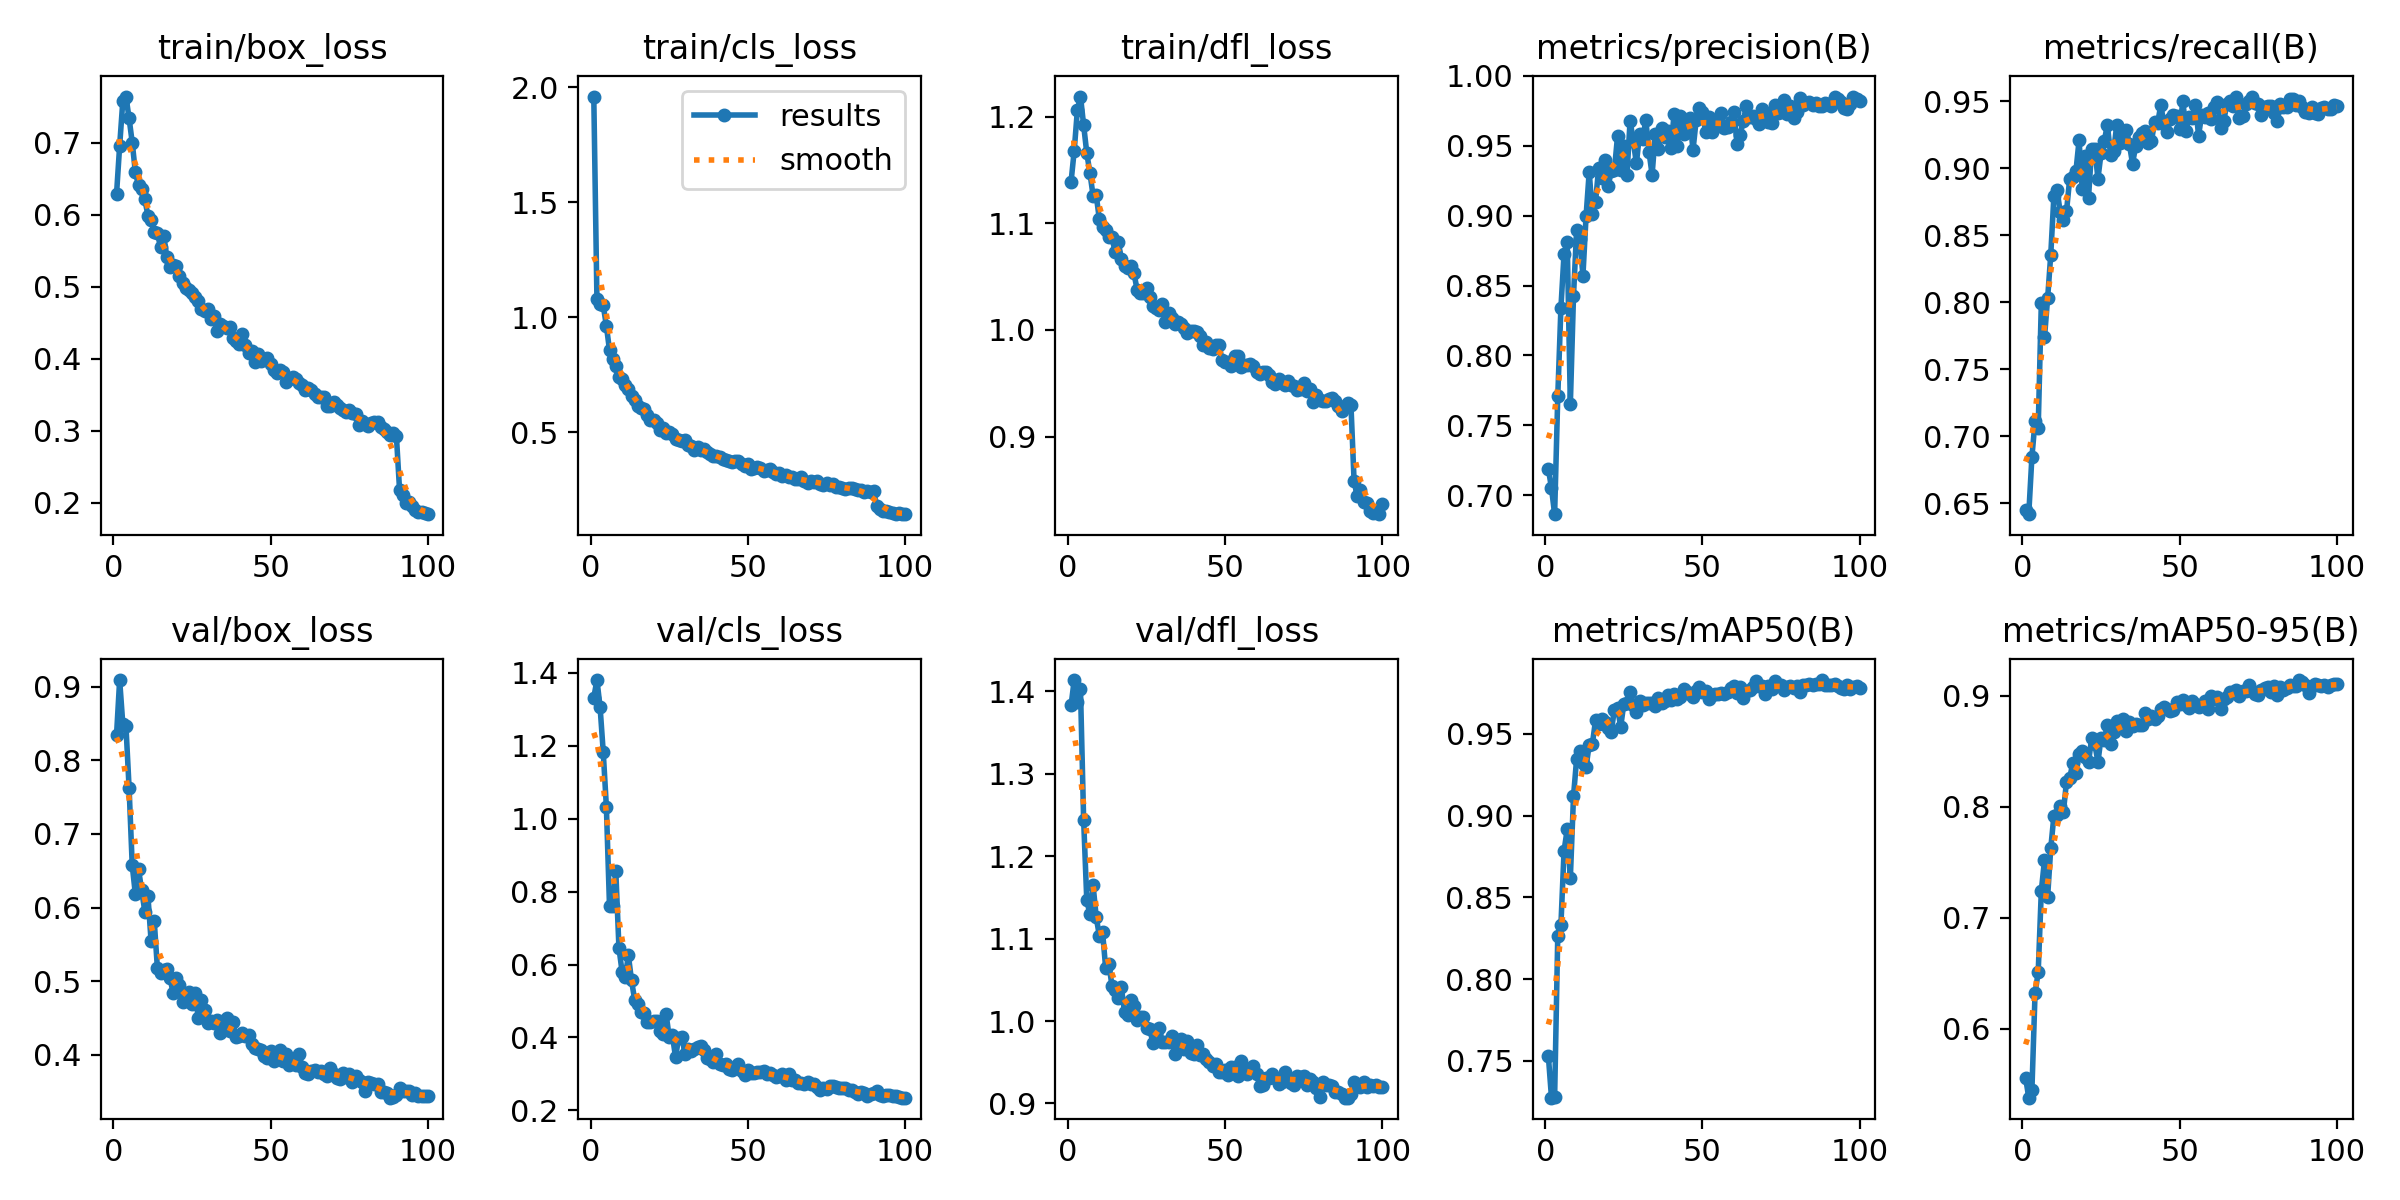


2. Confusion Matrix (Akurasi Spesifik per Kelas):


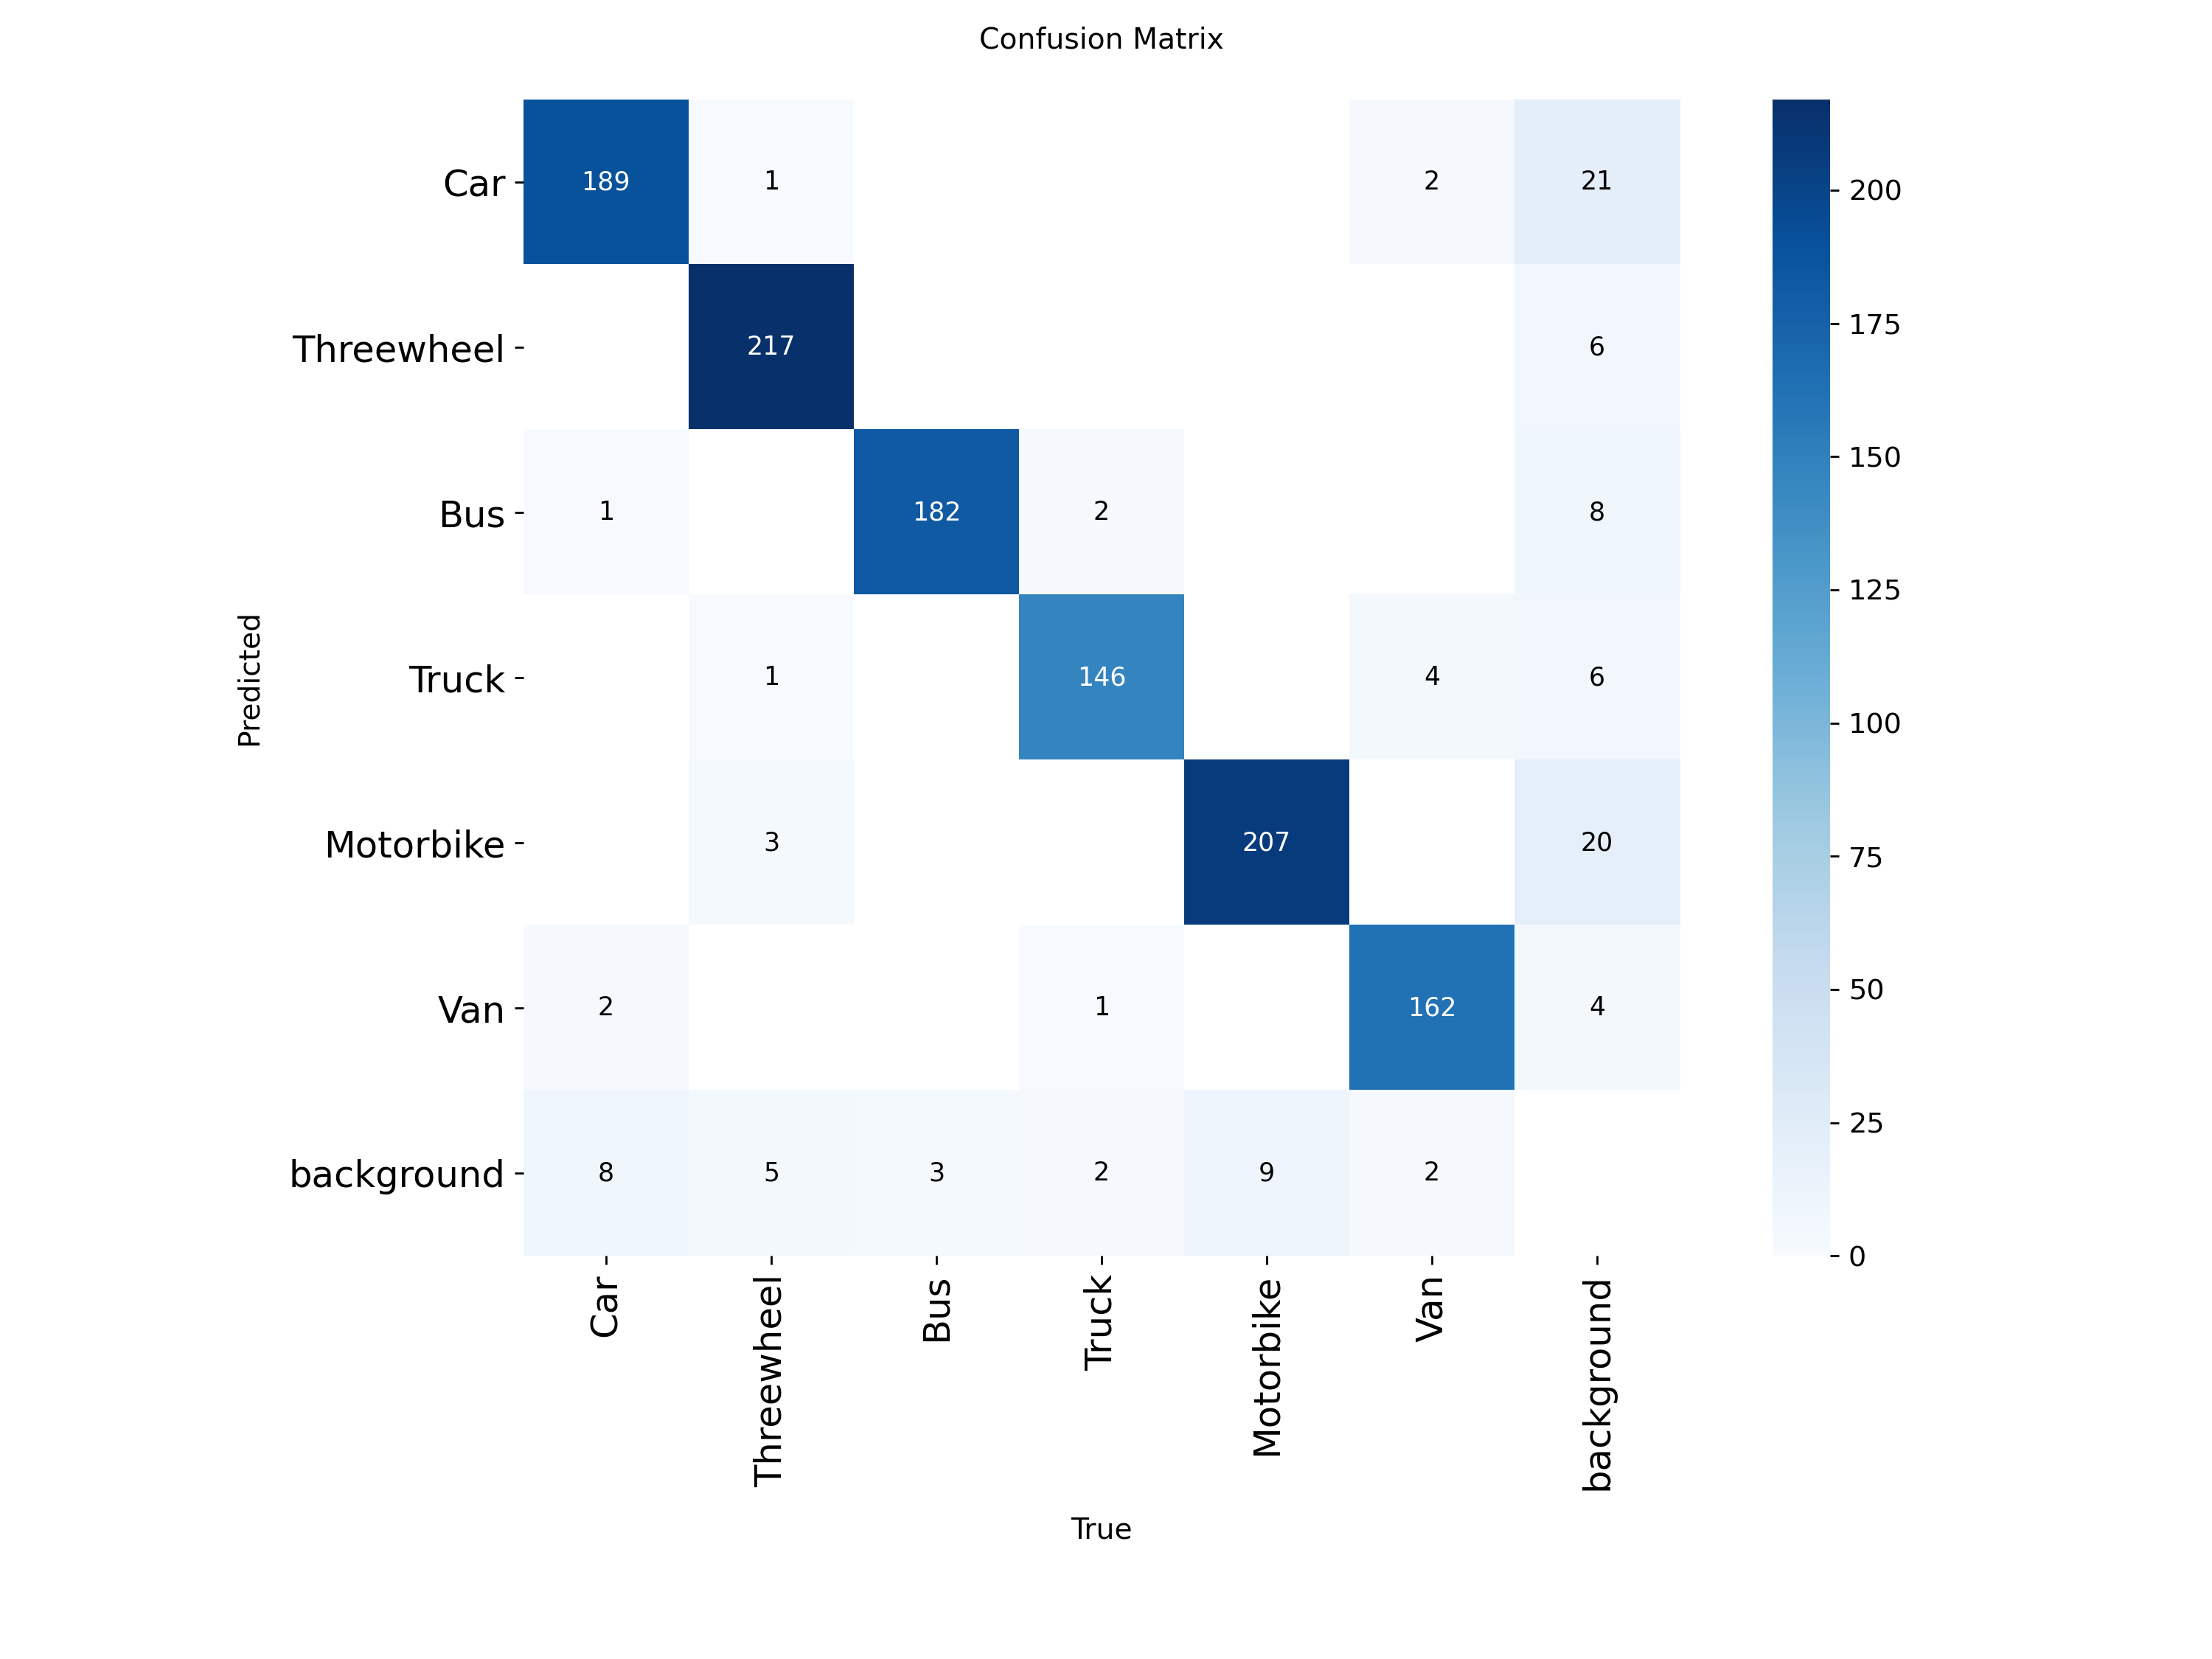

In [5]:
from IPython.display import Image, display

print("Memuat grafik evaluasi model untuk bahan presentasi web...")

# Mengarahkan ke folder tempat grafik training_run_v3 disimpan
# Catatan: Sesuaikan nama folder jika run sebelumnya menggunakan nama berbeda (misal: training_run_v32)
run_dir = os.path.dirname(os.path.dirname(best_model_path))

results_png = os.path.join(run_dir, 'results.png')
confusion_matrix = os.path.join(run_dir, 'confusion_matrix.png')

if os.path.exists(results_png):
    print("\n1. Grafik Metrik Training (Loss & mAP):")
    display(Image(filename=results_png, width=800))
else:
    print("Grafik results.png tidak ditemukan.")

if os.path.exists(confusion_matrix):
    print("\n2. Confusion Matrix (Akurasi Spesifik per Kelas):")
    display(Image(filename=confusion_matrix, width=600))
else:
    print("Grafik confusion_matrix.png tidak ditemukan.")

**Mendownload hasil terbaik dengan 10 sampel**

In [6]:
import shutil
from IPython.display import FileLink, display

print("Mempersiapkan aset untuk diunduh...")

# 1. Mengompresi direktori inference menjadi ZIP
inference_dir = '/kaggle/working/runs/detect/smart_traffic/inference_v3_results'
zip_name = '10_gambar_hasil_deteksi_final'

if os.path.exists(inference_dir):
    shutil.make_archive(zip_name, 'zip', inference_dir)
    print("File ZIP gambar berhasil dibuat.")
else:
    print("ERROR: Folder inference tidak ditemukan.")

# 2. Menggandakan dan mengganti nama model terbaik
output_model_name = 'yolov8s_smart_traffic_best.pt'
shutil.copy(best_model_path, output_model_name)
print("File model terbaik berhasil disiapkan.")

# 3. Menghasilkan tautan unduhan
print("\nPROSES SELESAI. Silakan klik kedua tautan di bawah ini untuk mengunduh file Anda:")
display(FileLink(f"{zip_name}.zip"))
display(FileLink(output_model_name))

Mempersiapkan aset untuk diunduh...
File ZIP gambar berhasil dibuat.
File model terbaik berhasil disiapkan.

PROSES SELESAI. Silakan klik kedua tautan di bawah ini untuk mengunduh file Anda:


/kaggle/working/10_gambar_hasil_deteksi_final.zip

/kaggle/working/yolov8s_smart_traffic_best.pt